In [1]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, 
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from joblib import parallel_backend
import warnings
import os

warnings.filterwarnings("ignore", category=UserWarning)

# LOAD DATA

print("Loading data...")
df_train = pd.read_csv("/Users/stephenwillis/Desktop/archive/cleaned_loan_data_dev.csv")
df_eval = pd.read_csv("/Users/stephenwillis/Desktop/archive/cleaned_loan_data_holdout.csv")

# Set index for both dataframes
df_train = df_train.set_index("Id")
df_eval = df_eval.set_index("Id")

# Split features and target
X_train = df_train.drop(columns=["Defaulted"])
y_train = df_train["Defaulted"]

X_eval = df_eval.drop(columns=["Defaulted"])
y_eval = df_eval["Defaulted"]  

print(f"Training set shape: {X_train.shape}")
print(f"Holdout set shape: {X_eval.shape}")


# PREPROCESSING PIPELINE

class WOEEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, features, eps=1e-4):
        self.features = features
        self.eps = eps
        self.woe_maps_ = {}
    
    def fit(self, X, y):
        for col in self.features:
            df = pd.concat([X[col], y], axis=1)
            grouped = df.groupby(col)[y.name].agg(['sum', 'count'])
            grouped["nevent"] = grouped["count"] - grouped["sum"]
            event_dist = grouped["sum"] / grouped["sum"].sum()
            nevent_dist = grouped["nevent"] / grouped["nevent"].sum()
            self.woe_maps_[col] = np.log((event_dist + self.eps) /
                                         (nevent_dist + self.eps)).to_dict()
        return self
    
    def transform(self, X):
        X_enc = X.copy()
        for col, mapping in self.woe_maps_.items():
            X_enc[col] = X_enc[col].map(mapping)
        return X_enc
    
    def set_output(self, *, transform=None):
        return self

# Define column types
num_cols = ["Term", "NoEmp", "ApprovalFY", "UrbanRural", "RevLineCr", 
            "LowDoc", "GrAppv", "SBA_Appv", "ExistingBusiness"]
cat_cols = [col for col in X_train.columns if col not in num_cols]

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy='median')),
    ("scale", RobustScaler())
])


cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy='most_frequent')),
    ("encode", WOEEncoder(features=cat_cols)),
    ("fill", SimpleImputer(strategy="constant", fill_value=0))
])

preproc = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
], remainder="drop")

preproc.set_output(transform="pandas")


# MODEL CONFIGURATION 

n_total = os.cpu_count()
n_best = max(1, n_total-1)

# Best Random Forest parameters
best_rf_params = {
    "n_jobs": n_best,
    "max_features": "log2",
    "max_samples": 0.5,
    "n_estimators": 100,
    "random_state": 42
}

# Best BorderlineSMOTE parameters
best_bsmote_params = {
    "sampling_strategy": 0.5,  
    "m_neighbors": 3,           
    "random_state": 42
}

# BUILD AND TRAIN FINAL MODEL

print("\nBuilding pipeline with BorderlineSMOTE...")

# Create the final pipeline with best configuration
final_pipeline = ImbPipeline([
    ("preproc", preproc),
    ("BorderlineSMOTE", BorderlineSMOTE(**best_bsmote_params)),
    ("model", RandomForestClassifier(**best_rf_params))
])

# Train on full dev set
print("Training model...")
#with parallel_backend("loky"):
final_pipeline.fit(X_train, y_train)

print("Training complete!")

# EVALUATE ON HOLDOUT SET

print("\nEvaluating on holdout set...")

# Get predictions and probabilities
y_pred = final_pipeline.predict(X_eval)
y_proba = final_pipeline.predict_proba(X_eval)[:, 1]

# Calculate metrics
metrics = {
    "Average Precision": average_precision_score(y_eval, y_proba),
    "ROC AUC": roc_auc_score(y_eval, y_proba),
    "Precision": precision_score(y_eval, y_pred),
    "Recall": recall_score(y_eval, y_pred),
    "F1 Score": f1_score(y_eval, y_pred)
}

# Print results
print("\n" + "="*50)
print("HOLDOUT SET PERFORMANCE")
print("="*50)
for metric_name, value in metrics.items():
    print(f"{metric_name:.<25} {value:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_eval, y_pred, 
                          target_names=['No Default', 'Default'],
                          digits=4))

# FEATURE IMPORTANCE ANALYSIS

# Extract components from pipeline
fitted_preproc = final_pipeline.named_steps["preproc"]
rf_model = final_pipeline.named_steps["model"]

# Get feature names after preprocessing
X_transformed = fitted_preproc.transform(X_train)
feature_names = X_transformed.columns
importances = rf_model.feature_importances_

# Create DataFrame and sort by importance
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Calculate cumulative importance
feat_imp_df['cumulative'] = feat_imp_df['importance'].cumsum()
feat_imp_df['cumulative_pct'] = (feat_imp_df['cumulative'] / 
                                  feat_imp_df['importance'].sum() * 100)

# Print feature importance list
print("\n" + "="*70)
print("FEATURE IMPORTANCE RANKING")
print("="*70)
print(f"{'Rank':<6}{'Feature':<35}{'Importance':<12}{'Cumulative %'}")
print("-"*70)

for i, (idx, row) in enumerate(feat_imp_df.iterrows(), 1):
    print(f"{i:<6}{row['feature'].split('__')[1]:<35}{row['importance']:<12.4f}{row['cumulative_pct']:>6.1f}%")
    
    # Add separator after top 10
    if i == 10:
        print("-"*70)

# Summary statistics
print("\n" + "="*70)
print("FEATURE IMPORTANCE SUMMARY")
print("="*70)
print(f"Total features: {len(feat_imp_df)}")
print(f"\nTop feature: {feat_imp_df.iloc[0]['feature'].split('__')[1]}")
print(f"Importance: {feat_imp_df.iloc[0]['importance']:.4f} ({feat_imp_df.iloc[0]['importance']/feat_imp_df['importance'].sum()*100:.1f}% of total)")

print(f"\nFeatures needed for cumulative importance:")
for threshold in [50, 80, 90, 95]:
    n_features = len(feat_imp_df[feat_imp_df['cumulative_pct'] <= threshold]) + 1
    n_features = min(n_features, len(feat_imp_df))
    print(f"  {threshold:>3}% importance: {n_features:>2} features")


Loading data...
Training set shape: (807450, 17)
Holdout set shape: (89717, 17)

Building pipeline with BorderlineSMOTE...
Training model...
Training complete!

Evaluating on holdout set...

HOLDOUT SET PERFORMANCE
Average Precision........ 0.9115
ROC AUC.................. 0.9744
Precision................ 0.8611
Recall................... 0.8457
F1 Score................. 0.8533

Classification Report:
              precision    recall  f1-score   support

  No Default     0.9673    0.9709    0.9691     73961
     Default     0.8611    0.8457    0.8533     15756

    accuracy                         0.9490     89717
   macro avg     0.9142    0.9083    0.9112     89717
weighted avg     0.9486    0.9490    0.9488     89717


FEATURE IMPORTANCE RANKING
Rank  Feature                            Importance  Cumulative %
----------------------------------------------------------------------
1     Term                               0.4375        43.7%
2     ApprovalFY                         0.

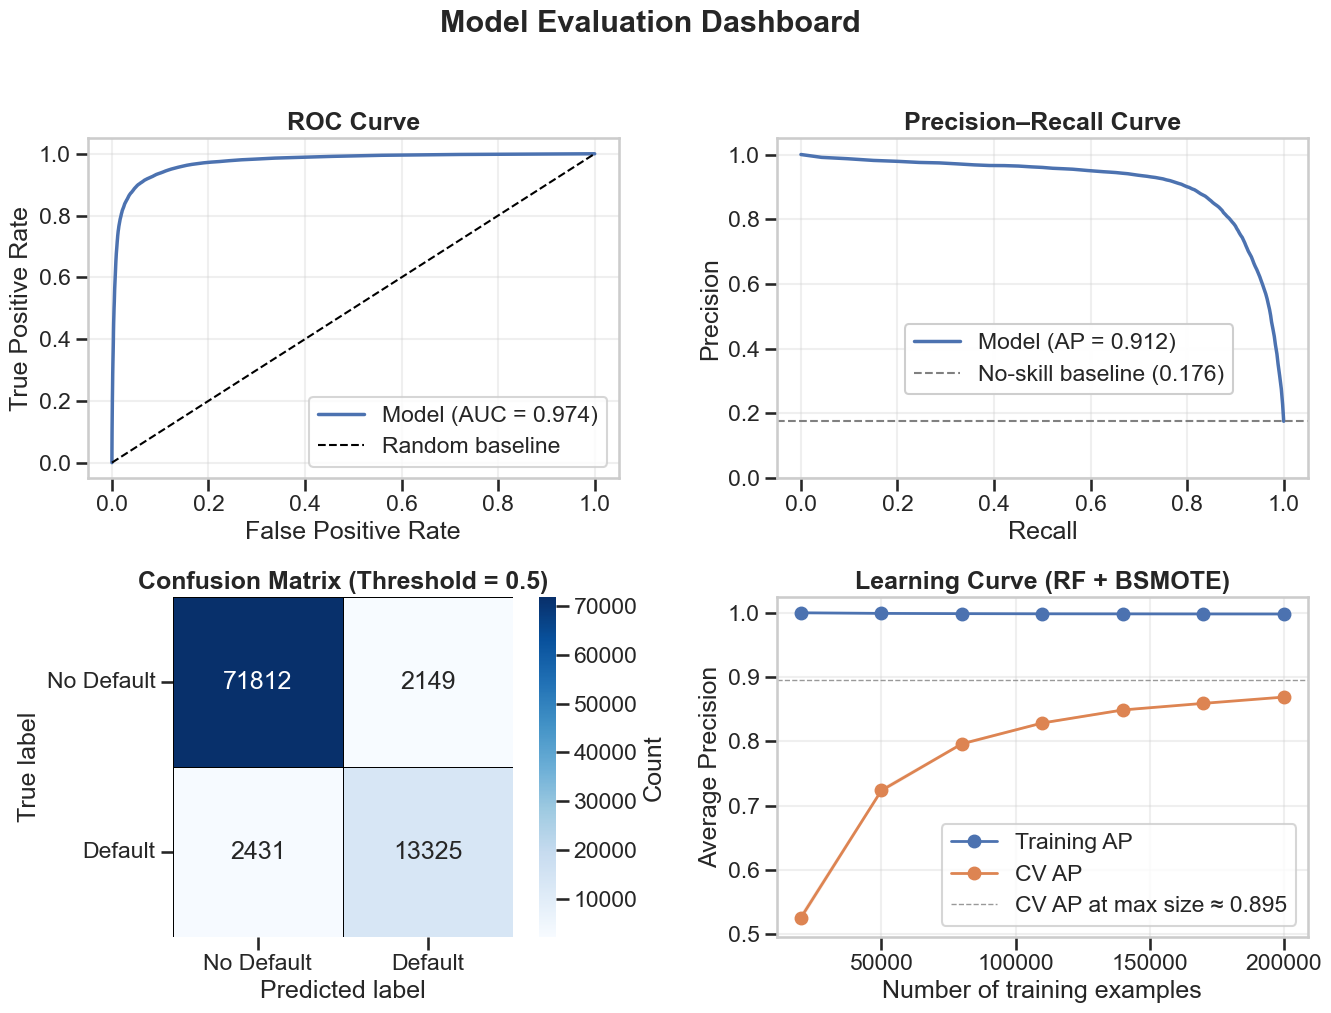

In [2]:
## EVALUATION PLOTS ##
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.model_selection import learning_curve, StratifiedKFold

# STYLE SETUP
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")      # larger fonts
sns.set_palette("deep")      # modern, muted palette

# LEARNING CURVE (AP vs training size) 

from sklearn.model_selection import learning_curve, StratifiedKFold

MAX_LC_SAMPLES = 300_000

if len(X_train) > MAX_LC_SAMPLES:
    lc_idx = X_train.sample(n=MAX_LC_SAMPLES, random_state=42).index
    X_lc = X_train.loc[lc_idx]
    y_lc = y_train.loc[lc_idx]
else:
    X_lc = X_train
    y_lc = y_train
    
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=final_pipeline,
    X=X_lc,
    y=y_lc,
    train_sizes=np.linspace(0.1, 1.0, 7),  # 7 points from 10% to 100%
    cv=cv,
    scoring="average_precision",
    n_jobs=1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

#  2×2 FIGURE
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# ROC Curve (top-left)
fpr, tpr, _ = roc_curve(y_eval, y_proba)
roc_auc = roc_auc_score(y_eval, y_proba)

ax1.plot(fpr, tpr, lw=2.5, label=f"Model (AUC = {roc_auc:.3f})")
ax1.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random baseline")

ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve", fontweight="bold")
ax1.legend(loc="lower right", frameon=True)
ax1.grid(True, alpha=0.3)

# Precision–Recall Curve (top-right)
precision, recall, _ = precision_recall_curve(y_eval, y_proba)
ap_score = average_precision_score(y_eval, y_proba)
positive_rate = y_eval.mean()

ax2.plot(
    recall,
    precision,
    lw=2.5,
    label=f"Model (AP = {ap_score:.3f})",
)

# No-skill baseline at the positive rate
ax2.axhline(
    y=positive_rate,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"No-skill baseline ({positive_rate:.3f})",
)

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision–Recall Curve", fontweight="bold")
ax2.set_ylim(0.0, 1.05)
ax2.grid(True, alpha=0.3)

ax2.legend(
    loc="center",
    bbox_to_anchor=(0.55, 0.35),
    frameon=True,
    framealpha=0.95,
)

# Confusion Matrix (bottom-left)
cm = confusion_matrix(y_eval, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar_kws={"label": "Count"},
    ax=ax3,
    square=True,
    linewidths=0.5,
    linecolor="black",
)

ax3.set_xlabel("Predicted label")
ax3.set_ylabel("True label")
ax3.set_title("Confusion Matrix (Threshold = 0.5)", fontweight="bold")
ax3.set_xticklabels(["No Default", "Default"], rotation=0)
ax3.set_yticklabels(["No Default", "Default"], rotation=0)

# Learning Curve (bottom-right)
ax4.plot(
    train_sizes,
    train_mean,
    "o-",
    lw=2.0,
    label="Training AP",
)
ax4.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
)

ax4.plot(
    train_sizes,
    val_mean,
    "o-",
    lw=2.0,
    label="CV AP",
)
ax4.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
)

ax4.axhline(
    y=0.895,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.8,
    label=f"CV AP at max size ≈ 0.895",
)

ax4.set_xlabel("Number of training examples")
ax4.set_ylabel("Average Precision")
ax4.set_title("Learning Curve (RF + BSMOTE)", fontweight="bold")
ax4.legend(loc="lower right", frameon=True)
ax4.grid(True, alpha=0.3)

# Overall title + layout
plt.suptitle("Model Evaluation Dashboard", fontsize=22, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=300, bbox_inches="tight")
plt.show()
